# Landing Analysis

In [245]:
import os
import tomllib
import json
from datetime import date
from pathlib import Path
from importlib import  reload

# Add the parent directory to the system path
import sys
sys.path.append(os.path.abspath('..'))

from src.data_loaders import read_telemetry_csv, load_runway_db
from src.parsers import extract_date_name_tacview
from src.transformer_plotter import (transform_telemetry, 
                                    touchdown_discovery,
                                    style_result_table,
                                    plot_landing_profile,
                                    touchdown_plotter)

# Load the configuration file
notebook_dir = Path.cwd()
config_path = notebook_dir.parent / "config.toml"
PROJECT_ROOT = config_path.parent.parent
with config_path.open('rb') as f:
    config = tomllib.load(f)

REF_PATH             = PROJECT_ROOT / Path(config["db_path"]["REF_PATH"])
RESULTS_DIR         = PROJECT_ROOT / Path(config["output"]["RESULTS_DIR"])

# Set the CSV path
# CSV_PATH            = PROJECT_ROOT / Path(config['input']['CSV_PATH'])
CSV_PATH = PROJECT_ROOT / Path(r'data\raw\Tacview-20260728-212004-DCS-Host-TOS1.csv')

In [246]:
# Make the output directory
record_date, mission_name = extract_date_name_tacview(CSV_PATH)
if record_date is None:
    record_date = date.today().strftime("%Y%m%d")

plots_output_path = RESULTS_DIR/f"[{record_date}] {mission_name}"
detailed_td_path = plots_output_path/"Detailed Touchdowns"

detailed_td_path.mkdir(parents=True, exist_ok=True)

## 1. Load DB once

In [247]:
# 1. Load DB
runway_db = load_runway_db(REF_PATH)

## 2. Touchdown Discovery

In [273]:
# 2. Touchdown Discovery

# Read the telemetry data
df = read_telemetry_csv(CSV_PATH)
# clean and transform the data
df_sub = transform_telemetry(df)
# Discover the touch downs
df_result = touchdown_discovery(df_sub, runway_db)

## 3. CSS Stylized Results Table

In [290]:
# 3. CSS Stylized Results Table
stylized_table = style_result_table(df_result, plots_output_path, record_date)
stylized_table

Exported styled HTML.
Exported table image.


Sortie,Touchdown Time,Aircraft,Pilot,CAS (kt),VS (fpm),Airport,Runway,Touchdown to Threshold (ft)
1,2016-07-21 02:51:32.096479,F-16C_50,< 404C > Rough14,151,-839,UGKO,25,921
1,2016-07-21 02:52:06.896446,F-16C_50,< 404C > Dragon 5,136,-554,UGKO,25,1257
1,2016-07-21 02:52:57.896397,F-16C_50,< 404C > Ghost,158,-31,UGKO,25,2333
1,2016-07-21 02:52:59.296396,F-16C_50,< 404C >Cooper,176,-497,UGKO,25,1398
1,2016-07-21 02:55:11.396270,F-16C_50,< 404C > Eclipse,164,-576,UGKO,25,1025
1,2016-07-21 02:55:18.296263,F-16C_50,<404>MOS,147,-388,UGKO,25,1974
1,2016-07-21 02:56:07.096217,F-16C_50,< 404C > IR.shadow,152,-352,UGKO,25,1792
2,2016-07-21 03:04:24.595742,F-16C_50,< 404C > Rough14,153,-1021,UGKO,25,1300
1,2016-07-21 03:17:08.595014,F-16C_50,< 404 > A D L E R,168,-825,Kutaisi West Airport,27,917
1,2016-07-21 03:17:12.695010,F-16C_50,< 404 > D1CE,169,-291,Kutaisi West Airport,27,2203


## 4. Plot Approach Profiles

Sortie #4 of < 404C > Phoenix Took less than 6 second!


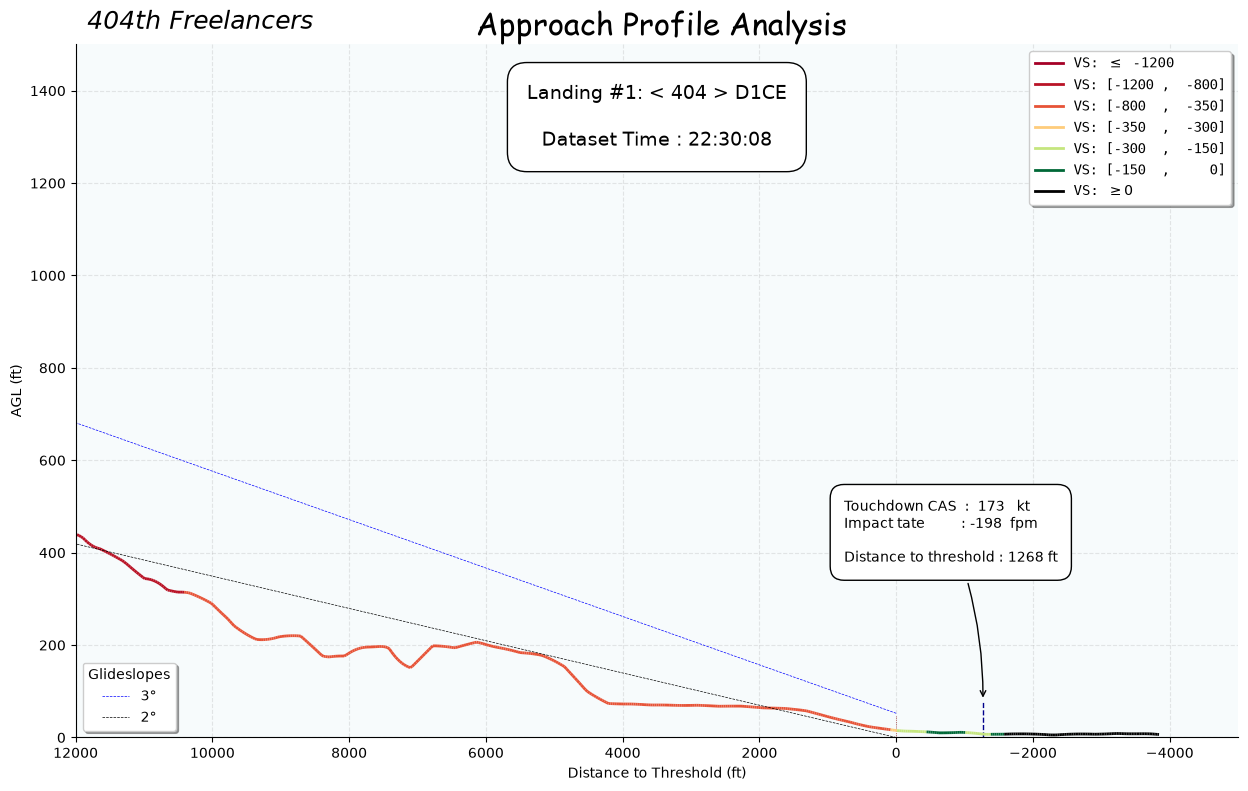

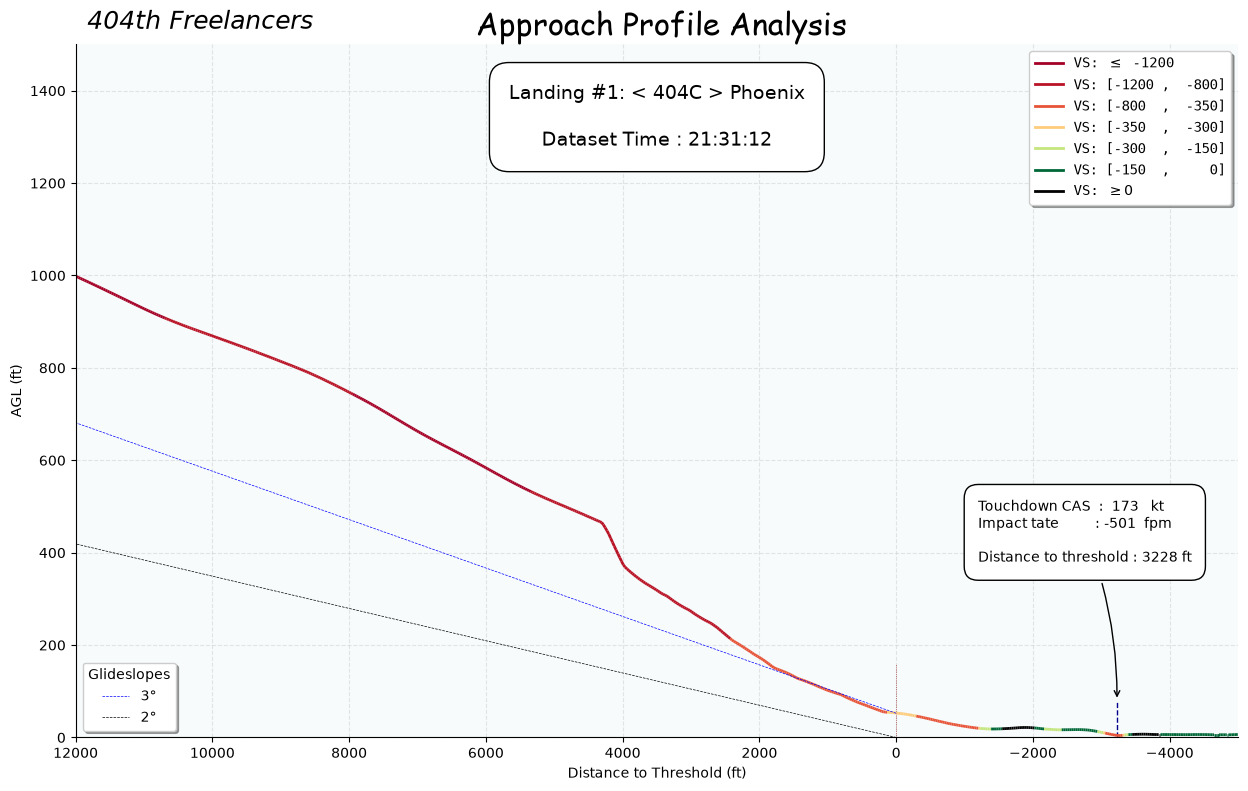

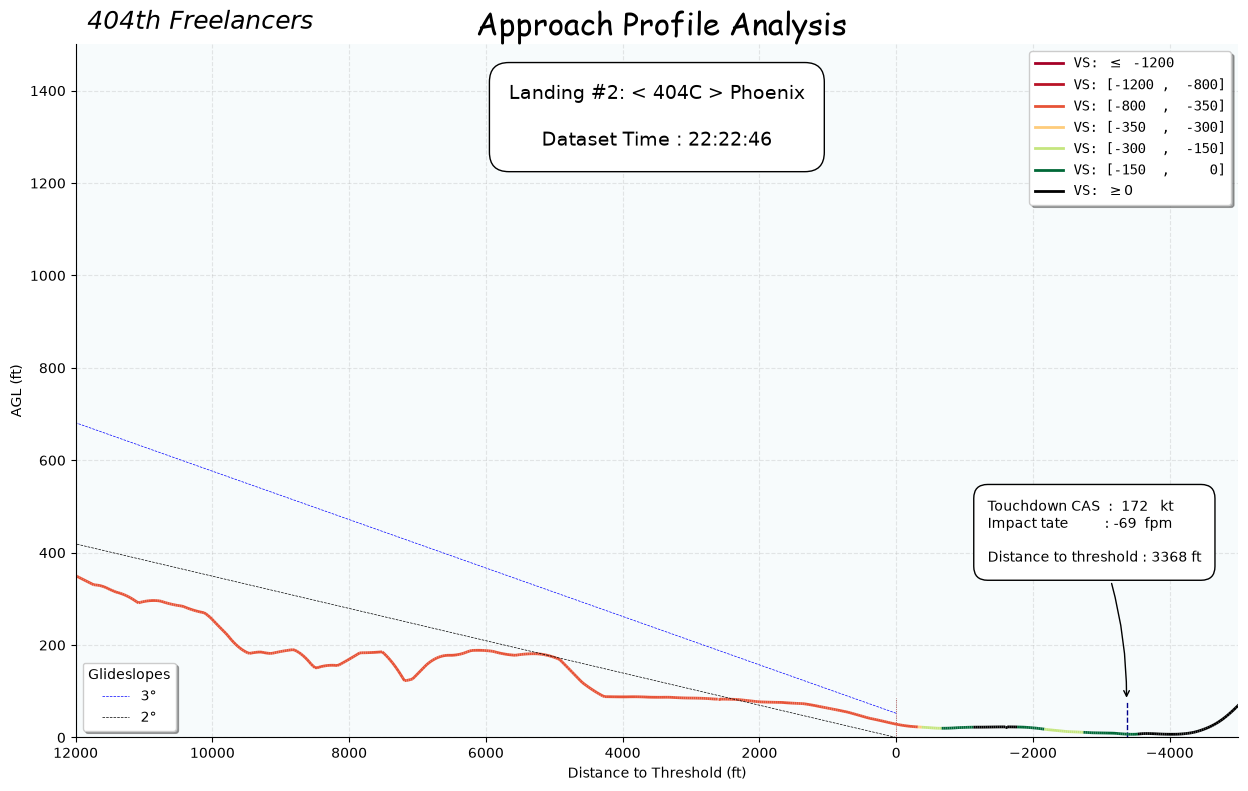

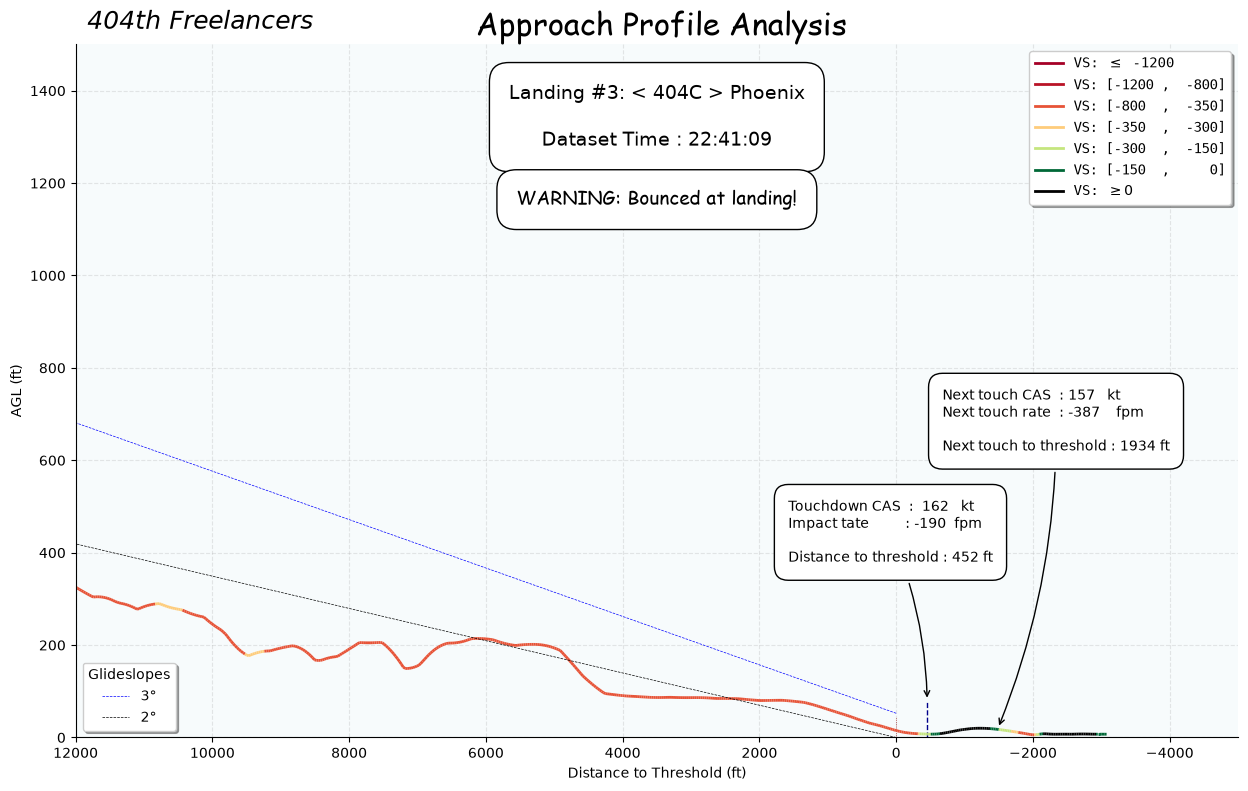

In [113]:
# 3. Plot/Export Profiles

for pilot in df_result['Pilot'].sort_values().unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        is_sortie = plot_landing_profile(df_sub, df_result, pilot, sortie_num, 
                                        plots_output_path, record_date)

## 5. Detailed Touchdowns (optional)

Sortie #4 of < 404C > Phoenix Took less than 6 second!


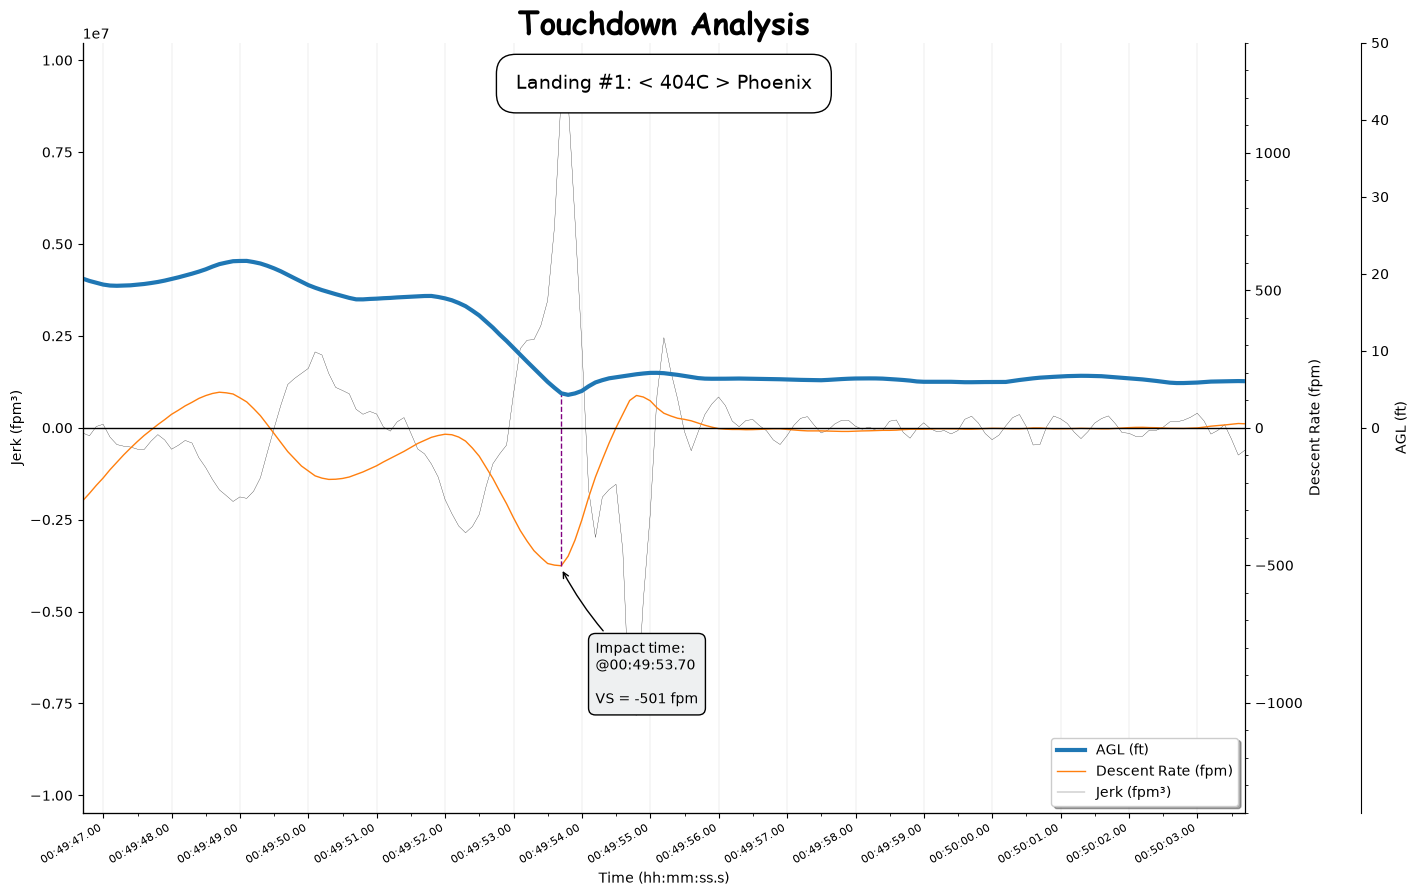

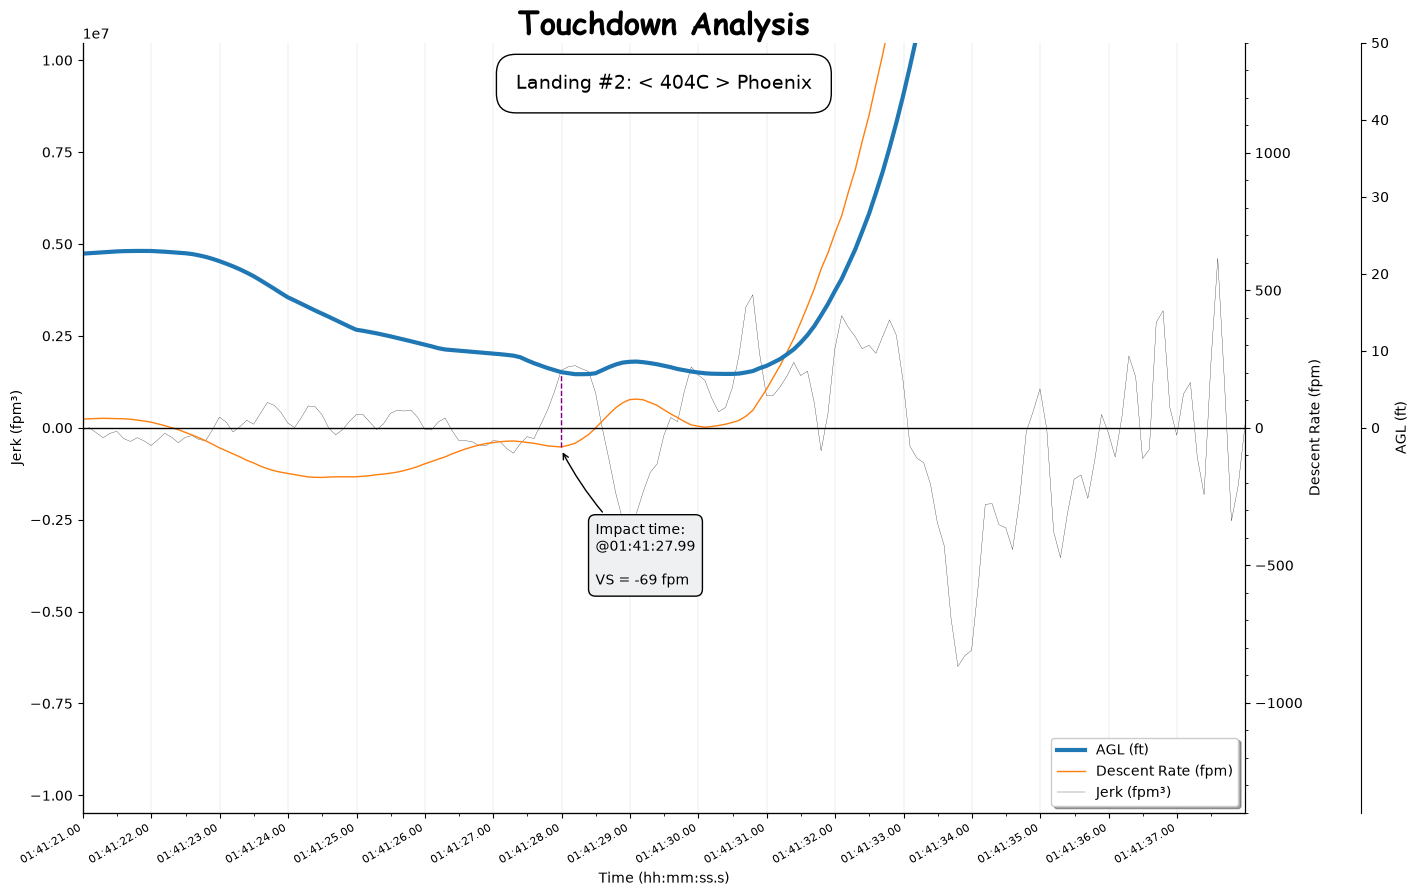

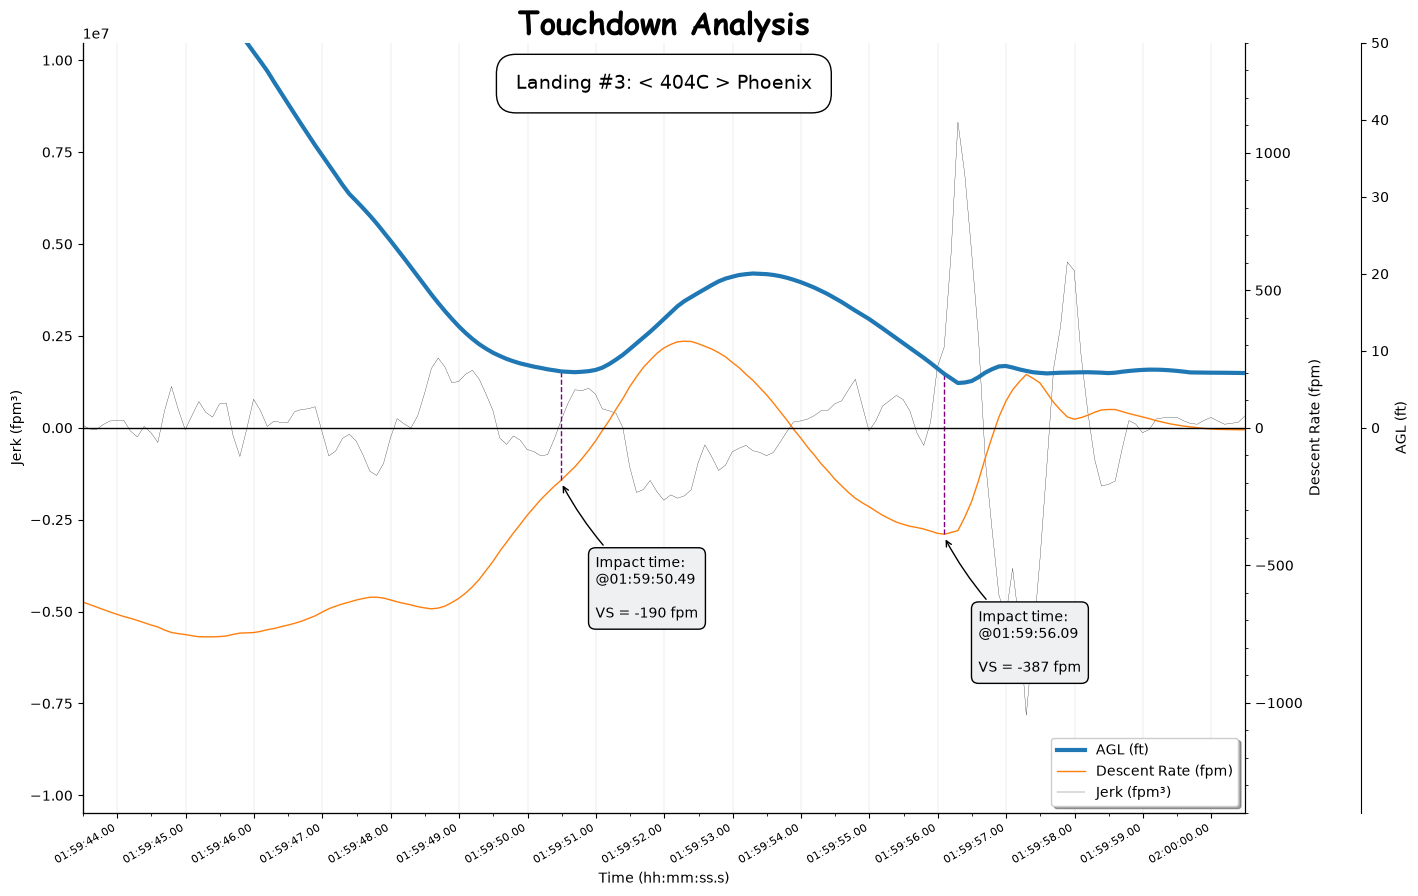

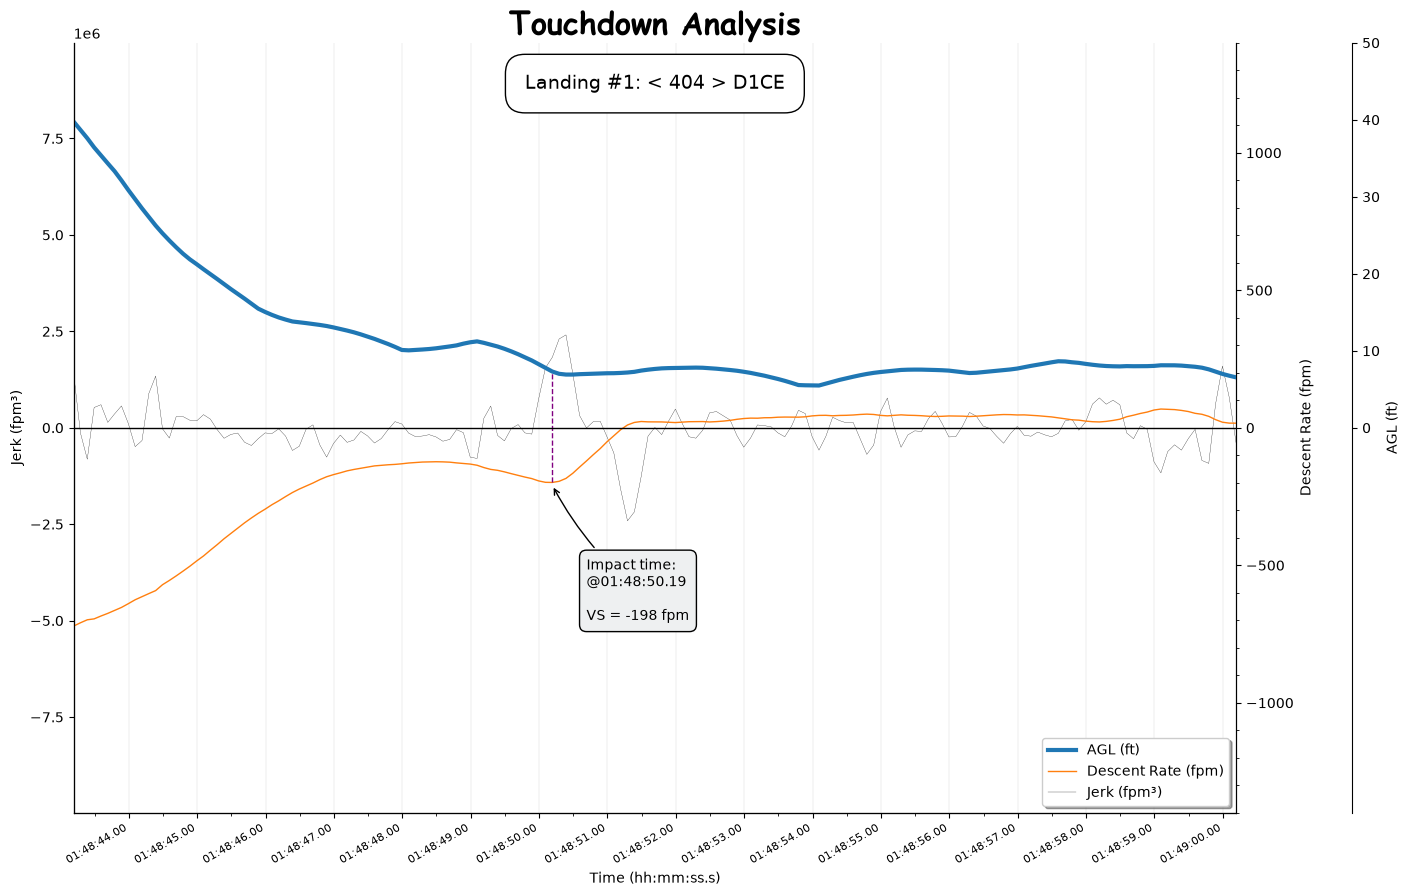

In [ ]:
# Plot/Export Touchdowns
for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(df_sub, df_result, pilot, sortie_num, detailed_td_path)